# Linear Regression-Based BTC Price Prediction and Trading Strategy

## 1. Overview

This part for our project applies **linear regression models** (OLS, Ridge, and Lasso) to predict Bitcoin's 30-minute forward returns and constructs a quantitative trading strategy based on the prediction signals.

### 1.1 Theoretical Background

**Linear Regression** assumes a linear relationship between the target variable $y$ and feature vector $\mathbf{x}$:

$$y = \mathbf{x}^T \boldsymbol{\beta} + \epsilon$$

where $\boldsymbol{\beta}$ is the parameter vector to be estimated, and $\epsilon$ is the error term.

**Regularization Methods** are used to prevent overfitting:

- **Ridge Regression (L2)**: $\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \alpha\|\boldsymbol{\beta}\|_2^2$
- **Lasso Regression (L1)**: $\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \alpha\|\boldsymbol{\beta}\|_1$

Ridge shrinks coefficients by penalizing their squared sum, while Lasso can produce sparse solutions (some coefficients become exactly zero).

### 1.2 Data and Features

- **Data Source**: BTC/USD 1-minute OHLCV data (2020-2025)
- **Macro Factors**: ETH/USD, EUR/USD, GLD (Gold ETF), SPY (S&P 500 ETF), VIXY (VIX Volatility ETF)
- **Feature Types**: Lagged returns, momentum, volatility, EMA deviation, volume ratios, price position, cross-market correlations

## 2. Environment Setup and Data Loading

In [1]:
# Import required libraries
import sys
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Add custom module path
module_dir = "/Users/yixuanwang/Desktop/BU/2025 Fall/MF703 E1 Programming for Mathematical Finance/Final Project/zk/bitcoinV2"
if module_dir not in sys.path:
    sys.path.append(module_dir)

from data_loader import build_merged_dataset
tz = "America/New_York"

In [2]:
# Data file path configuration
btc_path   = "/Users/yixuanwang/Desktop/BU/2025 Fall/MF703 E1 Programming for Mathematical Finance/Final Project/btcusd_1-min_data.csv"
eth_path   = "/Users/yixuanwang/Desktop/BU/2025 Fall/MF703 E1 Programming for Mathematical Finance/Final Project/Macro Factor/ETH_USD_1min_2020_2025.csv"
eurusd_path= "/Users/yixuanwang/Desktop/BU/2025 Fall/MF703 E1 Programming for Mathematical Finance/Final Project/Macro Factor/EUR_USD_1min_2020_2025.csv"
spy_path   = "/Users/yixuanwang/Desktop/BU/2025 Fall/MF703 E1 Programming for Mathematical Finance/Final Project/Macro Factor/SPY_1min_2020_2025.csv"
gld_path   = "/Users/yixuanwang/Desktop/BU/2025 Fall/MF703 E1 Programming for Mathematical Finance/Final Project/Macro Factor/GLD_1min_2020_2025.csv"
vixy_path  = "/Users/yixuanwang/Desktop/BU/2025 Fall/MF703 E1 Programming for Mathematical Finance/Final Project/Macro Factor/VIXY_1min_2020_2025.csv"

In [3]:
# Load and merge dataset
df_min = build_merged_dataset(
    btc_path=btc_path, eth_path=eth_path, eur_path=eurusd_path,
    gld_path=gld_path, spy_path=spy_path, vixy_path=vixy_path
)

# Keep required columns
keep_cols = ["Open", "High", "Low", "Close", "Volume",
             "ETH/USD_close", "EUR/USD_close", "GLD_close", "SPY_close", "VIXY_close"]
df_min = df_min[[c for c in keep_cols if c in df_min.columns]]

# Forward fill macro factors
macro_cols = ["ETH/USD_close", "EUR/USD_close", "GLD_close", "SPY_close", "VIXY_close"]
for col in macro_cols:
    if col in df_min.columns:
        df_min[col] = df_min[col].ffill().bfill()

# Fill BTC price data
df_min['Close'] = df_min['Close'].ffill()
df_min['Open'] = df_min['Open'].ffill()
df_min['High'] = df_min['High'].ffill()
df_min['Low'] = df_min['Low'].ffill()
df_min['Volume'] = df_min['Volume'].fillna(0)

Loading CSV files...
Aligning to BTC 7x24 timeline...
Merging all assets...
Adding US market trading hours flag...
Done! Final shape: (2999498, 29)


### 2.1 Data Summary

In [4]:
# Display data overview
print(f"Dataset Shape: {df_min.shape[0]:,} rows x {df_min.shape[1]} columns")
print(f"Time Range: {df_min.index.min()} to {df_min.index.max()}")
print(f"Duration: {(df_min.index.max() - df_min.index.min()).days:,} days")

Dataset Shape: 2,999,498 rows x 10 columns
Time Range: 2020-01-01 00:00:00-05:00 to 2025-09-14 19:57:00-04:00
Duration: 2,083 days


## 3. Feature Engineering

### 3.1 Target Variable Definition

We predict the **30-minute forward standardized log return**:

$$r_{t, t+30} = \ln\left(\frac{P_{t+30}}{P_t}\right)$$

Then apply rolling Z-score normalization:

$$y_t = \frac{r_{t, t+30} - \mu_{1440}}{\sigma_{1440}}$$

where $\mu_{1440}$ and $\sigma_{1440}$ are the rolling mean and standard deviation over the past 1440 minutes (1 day).

### 3.2 Feature Categories

| Category | Features | Description |
|----------|----------|-------------|
| Lagged Returns | ret_lag{1,5,10,30,60,120} | Returns at various lag intervals |
| Momentum | momentum_{5,10,30,60,120}m | Cumulative returns as momentum indicators |
| Volatility | vol_{30,60,120,240}m | Rolling return standard deviation |
| EMA Deviation | close_vs_ema{5,10,20,50,100} | Price deviation from EMA |
| Volume | volume_ratio_{30,60,120}m | Volume relative to moving average |
| Price Position | price_position_{30,60,120}m | Relative position within price range |
| Cross-Market | Macro factor returns & correlations | Captures inter-market dynamics |

In [5]:
# Target: 30-minute forward return (standardized)
df_min['target_raw'] = np.log(df_min['Close'].shift(-30) / df_min['Close'])
rolling_mean = df_min['target_raw'].rolling(1440, min_periods=100).mean()
rolling_std = df_min['target_raw'].rolling(1440, min_periods=100).std()
df_min['target'] = (df_min['target_raw'] - rolling_mean) / (rolling_std + 1e-8)

# BTC 1-minute return
df_min['ret_1m'] = np.log(df_min['Close'] / df_min['Close'].shift(1))

# ========== Macro Factor Returns ==========
ext_ret_cols = []
for col in macro_cols:
    ret_col = col.replace('_close', '_ret')
    df_min[ret_col] = np.log(df_min[col] / df_min[col].shift(1)).replace([np.inf, -np.inf], 0).fillna(0)
    ext_ret_cols.append(ret_col)

# ========== BTC Technical Features ==========
# Lagged returns
lag_windows = [1, 5, 10, 30, 60, 120]
for lag in lag_windows:
    df_min[f'ret_lag{lag}'] = df_min['ret_1m'].shift(lag)

# Momentum features
mom_windows = [5, 10, 30, 60, 120]
for w in mom_windows:
    df_min[f'momentum_{w}m'] = df_min['ret_1m'].rolling(w).sum().shift(1)

# Volatility features
vol_windows = [30, 60, 120, 240]
for w in vol_windows:
    df_min[f'vol_{w}m'] = df_min['ret_1m'].rolling(w).std().shift(1)

# EMA position features
ema_spans = [5, 10, 20, 50, 100]
for span in ema_spans:
    ema = df_min['Close'].ewm(span=span, adjust=False).mean()
    df_min[f'close_vs_ema{span}'] = (df_min['Close'] / ema - 1).shift(1)

df_min['ema5_vs_ema20'] = (df_min['Close'].ewm(5).mean() / df_min['Close'].ewm(20).mean() - 1).shift(1)
df_min['ema10_vs_ema50'] = (df_min['Close'].ewm(10).mean() / df_min['Close'].ewm(50).mean() - 1).shift(1)

# Volume features
df_min['volume_ret'] = np.log(df_min['Volume'] / df_min['Volume'].shift(1)).replace([np.inf, -np.inf], 0).fillna(0)
for w in [30, 60, 120]:
    df_min[f'volume_ratio_{w}m'] = (df_min['Volume'] / df_min['Volume'].rolling(w).mean()).shift(1)

# Price position features
df_min['bar_range'] = ((df_min['High'] - df_min['Low']) / df_min['Close']).shift(1)
for w in [30, 60, 120]:
    rh = df_min['High'].rolling(w).max()
    rl = df_min['Low'].rolling(w).min()
    df_min[f'price_position_{w}m'] = ((df_min['Close'] - rl) / (rh - rl + 1e-8)).shift(1)

# ========== Macro Factor Lags + Momentum ==========
for ret_col in ext_ret_cols:
    for lag in [1, 5, 10, 30]:
        df_min[f'{ret_col}_lag{lag}'] = df_min[ret_col].shift(lag)
    for w in [30, 60]:
        df_min[f'{ret_col}_mom{w}'] = df_min[ret_col].rolling(w).sum().shift(1)

# Cross-correlation features
for ret_col in ext_ret_cols:
    df_min[f'corr_btc_{ret_col}_60m'] = df_min['ret_1m'].rolling(60).corr(df_min[ret_col]).shift(1)

In [6]:
# Define feature sets
lag_features = [f'ret_lag{lag}' for lag in lag_windows]
momentum_features = [f'momentum_{w}m' for w in mom_windows]
vol_features = [f'vol_{w}m' for w in vol_windows]
ema_features = [f'close_vs_ema{span}' for span in ema_spans] + ['ema5_vs_ema20', 'ema10_vs_ema50']
price_features = ['bar_range'] + [f'price_position_{w}m' for w in [30, 60, 120]]
volume_features = ['volume_ret'] + [f'volume_ratio_{w}m' for w in [30, 60, 120]]

# Macro factor features
macro_lag_features = [f'{ret_col}_lag{lag}' for ret_col in ext_ret_cols for lag in [1, 5, 10, 30]]
macro_mom_features = [f'{ret_col}_mom{w}' for ret_col in ext_ret_cols for w in [30, 60]]
corr_features = [f'corr_btc_{ret_col}_60m' for ret_col in ext_ret_cols]

# Technical feature set
tech_features = lag_features + momentum_features + vol_features + ema_features + price_features + volume_features

# Tech + Macro feature set
tech_macro_features = tech_features + macro_lag_features + macro_mom_features + corr_features

# Filter existing columns
tech_features = [c for c in tech_features if c in df_min.columns]
tech_macro_features = [c for c in tech_macro_features if c in df_min.columns]

# Use Tech+Macro feature set
feature_cols = tech_macro_features

print(f"Technical Features: {len(tech_features)}")
print(f"Technical + Macro Features: {len(tech_macro_features)}")

Technical Features: 30
Technical + Macro Features: 65


## 4. Model Training and Evaluation

### 4.1 Data Split Strategy

We use **time-series split** with the last 14 days as the test set. This approach prevents information leakage and better reflects real trading scenarios.

### 4.2 Evaluation Metrics

| Metric | Description |
|--------|-------------|
| **IC (Information Coefficient)** | Pearson correlation between predictions and actual values |
| **Rank IC** | Spearman rank correlation, measures ranking accuracy |
| **Win Rate** | Proportion of correct directional predictions |
| **RMSE** | Root Mean Squared Error, measures prediction accuracy |

In [7]:
# Train/Test split (last 14 days for testing)
idx = df_min.index
latest_date = idx.max()
test_start = latest_date - pd.Timedelta(days=14)

train_mask = (idx >= pd.Timestamp('2020-01-01', tz=tz)) & (idx < test_start)
test_mask = (idx >= test_start) & (idx <= latest_date)

print(f"Latest Date: {latest_date}")
print(f"Test Start: {test_start}")
print(f"Train Samples: {train_mask.sum():,} | Test Samples: {test_mask.sum():,}")

Latest Date: 2025-09-14 19:57:00-04:00
Test Start: 2025-08-31 19:57:00-04:00
Train Samples: 2,979,337 | Test Samples: 20,161


In [8]:
# Prepare features and target
X = df_min[feature_cols].fillna(0)
y = df_min['target']

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Remove rows with NaN target
valid_train = y_train.notna()
valid_test = y_test.notna()
X_train, y_train = X_train[valid_train], y_train[valid_train]
X_test, y_test = X_test[valid_test], y_test[valid_test]

print(f"Training Samples: {len(y_train):,} | Test Samples: {len(y_test):,}")

# Standardize features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Train Ridge model
model = Ridge(alpha=1.0)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

# Calculate metrics
ic = np.corrcoef(y_test.values, y_pred)[0, 1]
win_rate = ((y_test.values * y_pred) > 0).mean()

Training Samples: 2,979,238 | Test Samples: 20,131


### 4.3 Model Comparison

We compare three linear models:
- **OLS (Ordinary Least Squares)**: No regularization
- **Ridge**: L2 regularization, shrinks all coefficients
- **Lasso**: L1 regularization, produces sparse solutions

In [9]:
# Model comparison
results = []
for name, mdl in [('OLS', LinearRegression()), ('Ridge', Ridge(alpha=1.0)), ('Lasso', Lasso(alpha=0.001))]:
    mdl.fit(X_train_s, y_train)
    pred = mdl.predict(X_test_s)
    results.append({
        'Model': name,
        'IC': np.corrcoef(y_test.values, pred)[0, 1],
        'Rank_IC': spearmanr(y_test.values, pred)[0],
        'Win_Rate': ((y_test.values * pred) > 0).mean(),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })

results_df = pd.DataFrame(results).sort_values('IC', ascending=False)
results_df

,Model,IC,Rank_IC,Win_Rate,RMSE
0,OLS,0.064889,0.079886,0.531071,1.055995
1,Ridge,0.064786,0.079788,0.531071,1.055999
2,Lasso,0.030644,0.045251,0.513685,1.057156


### 4.4 Model Performance Interpretation

**Key Findings:**

1. **IC ~ 0.065**: The Information Coefficient indicates a weak but statistically significant linear relationship between predictions and actual returns. In quantitative finance, IC > 0.05 is generally considered meaningful for high-frequency strategies.

2. **Win Rate ~ 53%**: Slightly better than random (50%), suggesting the model captures some predictive signal. Even small edges can be profitable with sufficient trading frequency.

3. **OLS vs Ridge**: Nearly identical performance indicates low multicollinearity in features. Ridge's regularization provides robustness without sacrificing accuracy.

4. **Lasso underperformance**: The lower IC suggests that feature sparsity hurts prediction in this context; all features contribute marginally.

## 5. Trading Strategy Backtest

### 5.1 Signal Generation

We convert model predictions to trading signals using the **tanh function**:

$$\text{signal} = \tanh(\text{scale} \times \hat{y})$$

This maps predictions to the range [-1, 1], where:
- +1 = Full long position
- -1 = Full short position
- 0 = No position

### 5.2 Strategy Variants

| Strategy | Threshold | Transaction Cost | Description |
|----------|-----------|------------------|-------------|
| Ideal | 0.0 | 0 | Upper bound performance |
| Aggressive | 0.2 | 0 | Trade on moderate signals |
| Conservative | 0.6 | 1bp | Trade only on strong signals with costs |

In [10]:
def get_tanh_signal(predictions, scale=10.0):
    """
    Convert predictions to continuous signal in [-1, 1] using tanh.
    
    Parameters
    ----------
    predictions : array-like
        Model predictions (any range)
    scale : float
        Scaling factor to control tanh sensitivity
        
    Returns
    -------
    signals : np.array
        Continuous signals in range [-1, 1]
    """
    predictions = np.array(predictions)
    signals = np.tanh(predictions * scale)
    return signals


def backtest_strategy(signals, real_step_returns, threshold=0.0, cost_rate=0.0):
    """
    Backtest trading strategy with given signals.
    
    Parameters
    ----------
    signals : array-like
        Trading signals in [-1, 1]
    real_step_returns : array-like
        Actual 1-min log returns
    threshold : float
        Signal threshold, only trade when |signal| > threshold
    cost_rate : float
        Transaction cost rate (e.g., 0.0001 = 1bp)
        
    Returns
    -------
    dict
        Contains equity curves and performance metrics
    """
    signals = np.array(signals)
    real_step_returns = np.array(real_step_returns)
    
    # Apply threshold to get position
    position = np.where(np.abs(signals) > threshold, signals, 0)
    
    # Calculate transaction costs
    position_change = np.abs(np.diff(np.concatenate([[0], position])))
    costs = position_change * cost_rate
    
    # Strategy returns = position * actual returns - costs
    strategy_returns = position * real_step_returns - costs
    
    # Buy & Hold returns
    bh_returns = real_step_returns
    
    # Equity curves (starting from 1)
    equity_strat = np.exp(np.cumsum(strategy_returns))
    equity_bh = np.exp(np.cumsum(bh_returns))
    
    # Calculate metrics
    total_return_strat = (equity_strat[-1] - 1) * 100
    total_return_bh = (equity_bh[-1] - 1) * 100
    
    # Annualized Sharpe (1440 mins/day, 252 trading days)
    annual_factor = 252 * 1440
    sharpe_strat = (np.mean(strategy_returns) / np.std(strategy_returns)) * np.sqrt(annual_factor) if np.std(strategy_returns) > 0 else 0
    
    # Max Drawdown
    cum_strat = np.cumsum(strategy_returns)
    max_dd_strat = (np.exp(np.min(cum_strat - np.maximum.accumulate(cum_strat))) - 1) * 100
    
    # Win Rate (only for traded bars)
    traded_mask = position != 0
    traded_returns = strategy_returns[traded_mask]
    win_rate = (traded_returns > 0).mean() * 100 if len(traded_returns) > 0 else 0
    
    # Trade ratio
    trade_ratio = traded_mask.mean() * 100
    
    metrics = {
        'Total Return (%)': f'{total_return_strat:.2f}',
        'Buy&Hold Return (%)': f'{total_return_bh:.2f}',
        'Sharpe Ratio': f'{sharpe_strat:.2f}',
        'Max Drawdown (%)': f'{max_dd_strat:.2f}',
        'Win Rate (%)': f'{win_rate:.2f}',
        'Trade Ratio (%)': f'{trade_ratio:.2f}',
        'Num Trades': f'{int(traded_mask.sum())}',
    }
    
    return {
        'equity_strat': equity_strat,
        'equity_bh': equity_bh,
        'metrics': metrics,
        'signals': signals,
        'position': position,
        'strategy_returns': strategy_returns,
    }

In [11]:
# Get test index and 1-min returns
test_idx = y_test.index
real_step_returns = df_min.loc[test_idx, 'ret_1m'].values
real_step_returns = np.nan_to_num(real_step_returns)

# Generate tanh signals
signals = get_tanh_signal(y_pred, scale=10.0)

# Run backtest with different configurations
res_ideal = backtest_strategy(signals, real_step_returns, threshold=0.0, cost_rate=0.0)
res_aggressive = backtest_strategy(signals, real_step_returns, threshold=0.2, cost_rate=0.0)
res_conservative = backtest_strategy(signals, real_step_returns, threshold=0.6, cost_rate=0.0001)

TEST_DAYS = (test_idx.max() - test_idx.min()).days

### 5.3 Strategy Performance Comparison

In [12]:
# Create performance comparison table
comparison_data = {
    'Metric': list(res_ideal['metrics'].keys()),
    'Ideal (No Cost)': list(res_ideal['metrics'].values()),
    'Aggressive (T=0.2)': list(res_aggressive['metrics'].values()),
    'Conservative (T=0.6, 1bp)': list(res_conservative['metrics'].values())
}
comparison_df = pd.DataFrame(comparison_data)
print(f"Strategy Performance Comparison (Test Period: {TEST_DAYS} days)")

comparison_df

Strategy Performance Comparison (Test Period: 13 days)


,Metric,Ideal (No Cost),Aggressive (T=0.2),"Conservative (T=0.6, 1bp)"
0,Total Return (%),-0.03,-0.27,-1.35
1,Buy&Hold Return (%),6.67,6.67,6.67
2,Sharpe Ratio,-0.05,-0.59,-4.38
3,Max Drawdown (%),-1.34,-1.34,-1.75
4,Win Rate (%),45.94,45.78,47.13
5,Trade Ratio (%),100.00,55.15,3.98
6,Num Trades,20131,11103,802


## 6. Visualization

### 6.1 Signal Distribution Analysis

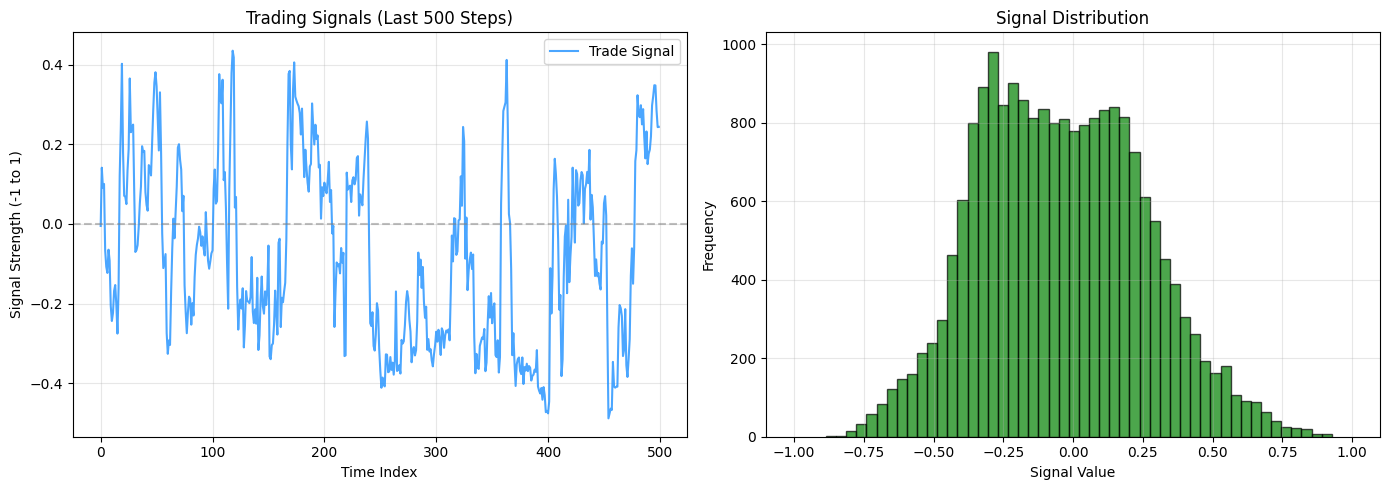

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Signal time series (last 500 points)
ax = axes[0]
ax.plot(signals[-500:], label='Trade Signal', color='dodgerblue', alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Trading Signals (Last 500 Steps)')
ax.set_ylabel('Signal Strength (-1 to 1)')
ax.set_xlabel('Time Index')
ax.legend()
ax.grid(True, alpha=0.3)

# Signal histogram
ax = axes[1]
ax.hist(signals, bins=50, color='green', alpha=0.7, edgecolor='black')
ax.set_title('Signal Distribution')
ax.set_xlabel('Signal Value')
ax.set_ylabel('Frequency')
ax.set_xlim(-1.1, 1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Backtest Performance Visualization

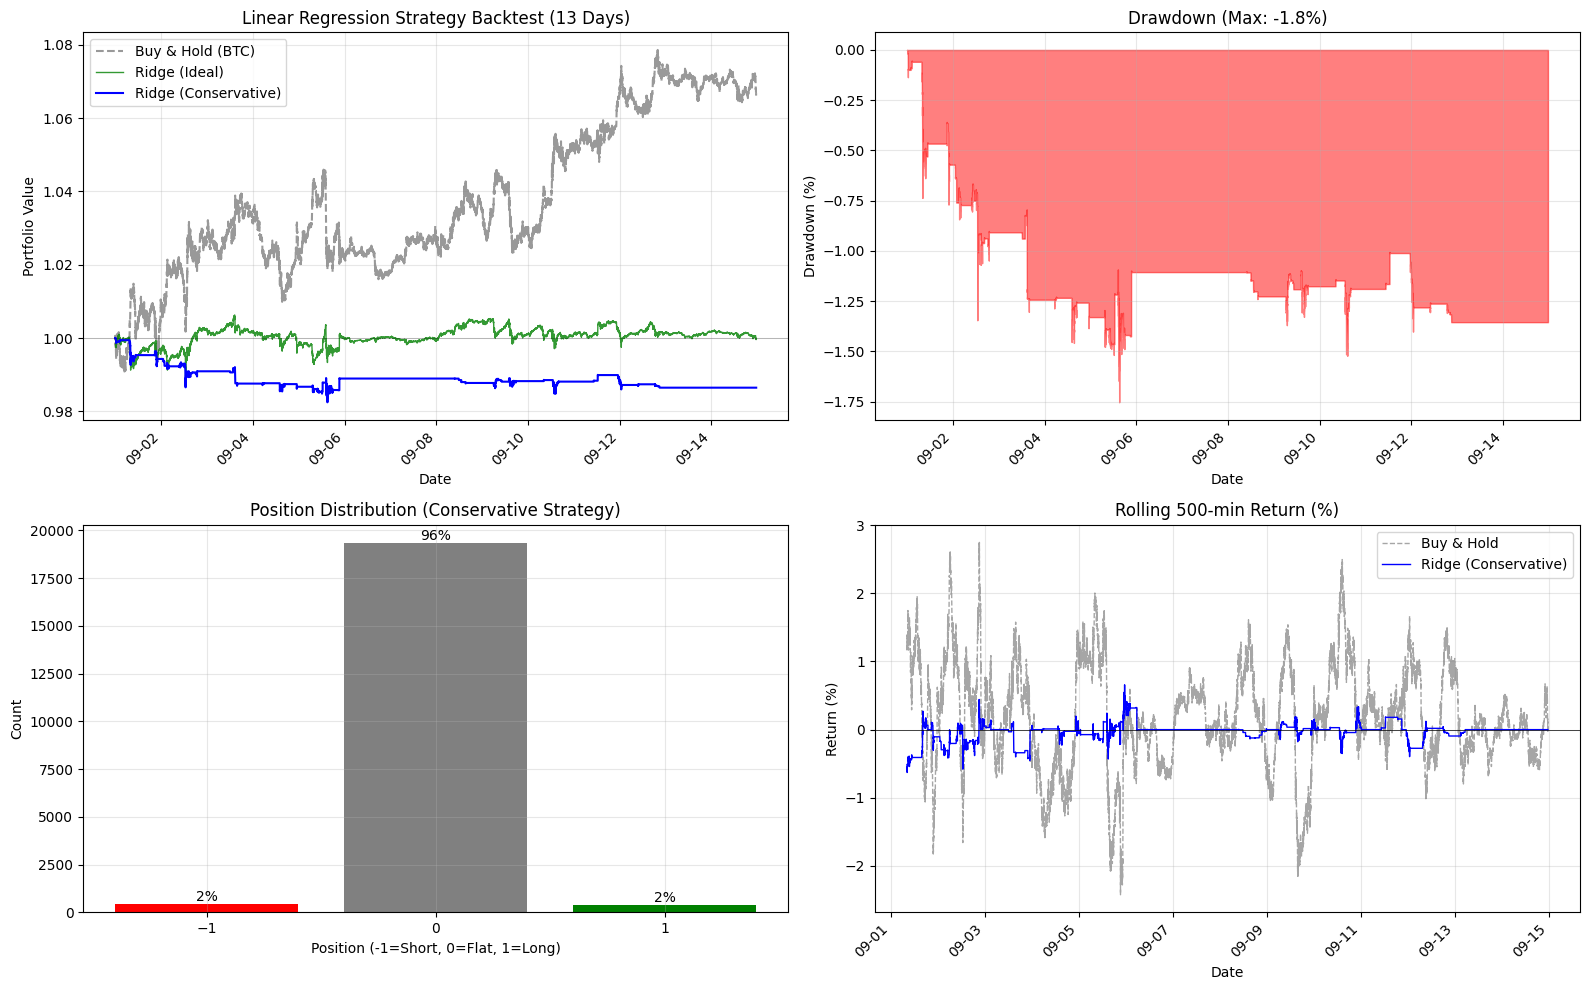

In [14]:
# Use datetime index for x-axis
time_index = test_idx[:len(res_ideal['equity_bh'])]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Plot 1: Equity Curves ---
ax = axes[0, 0]
ax.plot(time_index, res_ideal['equity_bh'], '--', color='gray', lw=1.5, label='Buy & Hold (BTC)', alpha=0.8)
ax.plot(time_index, res_ideal['equity_strat'], color='green', lw=1, label='Ridge (Ideal)', alpha=0.8)
ax.plot(time_index, res_conservative['equity_strat'], color='blue', lw=1.5, label='Ridge (Conservative)')
ax.axhline(1, color='black', lw=0.5, alpha=0.3)
ax.set_title(f'Linear Regression Strategy Backtest ({TEST_DAYS} Days)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# --- Plot 2: Drawdown ---
ax = axes[0, 1]
cum = np.cumsum(res_conservative['strategy_returns'])
dd = (np.exp(cum - np.maximum.accumulate(cum)) - 1) * 100
ax.fill_between(time_index, dd, 0, color='red', alpha=0.5)
ax.set_title(f'Drawdown (Max: {dd.min():.1f}%)')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# --- Plot 3: Position Distribution ---
ax = axes[1, 0]
position = res_conservative['position']
pos_counts = pd.Series(position).apply(lambda x: 1 if x > 0.3 else (-1 if x < -0.3 else 0)).value_counts().reindex([-1, 0, 1], fill_value=0)
colors = ['red', 'gray', 'green']
bars = ax.bar(pos_counts.index, pos_counts.values, color=colors)
ax.set_title('Position Distribution (Conservative Strategy)')
ax.set_xlabel('Position (-1=Short, 0=Flat, 1=Long)')
ax.set_ylabel('Count')
ax.set_xticks([-1, 0, 1])
for bar, count in zip(bars, pos_counts.values):
    pct = count / len(position) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{pct:.0f}%', ha='center', va='bottom')
ax.grid(True, alpha=0.3)

# --- Plot 4: Rolling Returns ---
ax = axes[1, 1]
window = 500
ret_strat = res_conservative['strategy_returns']
rolling_bh = pd.Series(np.log(res_ideal['equity_bh'])).diff().rolling(window).sum() * 100
rolling_strat = pd.Series(ret_strat).rolling(window).sum() * 100
ax.plot(time_index, rolling_bh.values, '--', color='gray', lw=1, label='Buy & Hold', alpha=0.7)
ax.plot(time_index, rolling_strat.values, color='blue', lw=1, label='Ridge (Conservative)')
ax.axhline(0, color='black', lw=0.5)
ax.set_title(f'Rolling {window}-min Return (%)')
ax.set_xlabel('Date')
ax.set_ylabel('Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 6.3 Prediction Error Analysis

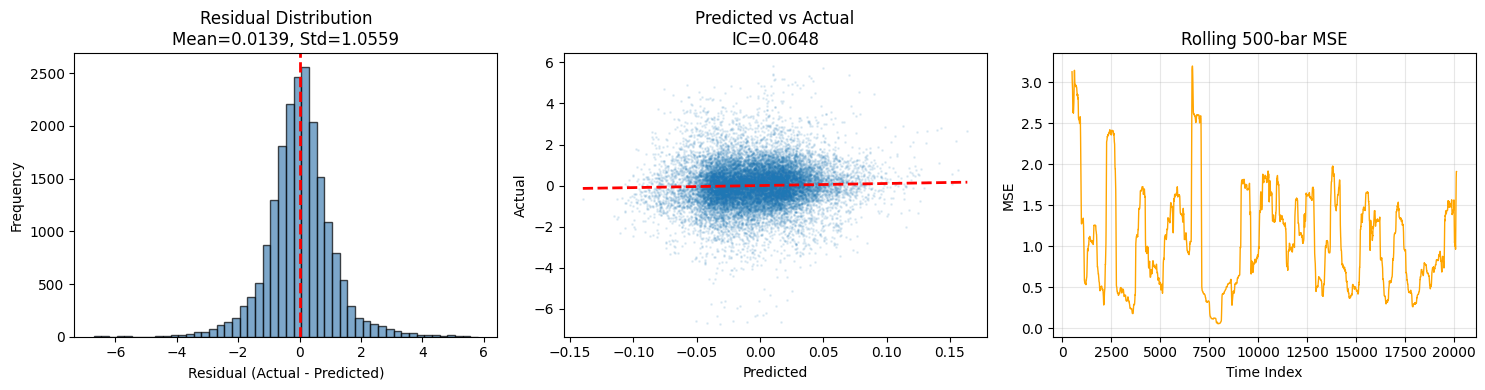

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residual distribution
residuals = y_test.values - y_pred
ax = axes[0]
ax.hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.set_title(f'Residual Distribution\nMean={residuals.mean():.4f}, Std={residuals.std():.4f}')
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Frequency')

# Predicted vs Actual
ax = axes[1]
ax.scatter(y_pred, y_test.values, alpha=0.1, s=1)
ax.plot([y_pred.min(), y_pred.max()], [y_pred.min(), y_pred.max()], 'r--', lw=2)
ax.set_title(f'Predicted vs Actual\nIC={ic:.4f}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# Rolling MSE
window = 500
rolling_mse = pd.Series((y_test.values - y_pred)**2).rolling(window).mean()
ax = axes[2]
ax.plot(rolling_mse.values, color='orange', lw=1)
ax.set_title(f'Rolling {window}-bar MSE')
ax.set_xlabel('Time Index')
ax.set_ylabel('MSE')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Create results
ridge_results = pd.DataFrame({
    'y_true': y_test.values,                           # True target values
    'y_pred': y_pred,                                  # Model predictions
    'signals': signals,                                # Tanh signals [-1, 1]
    'benchmark': res_ideal['equity_bh'],               # Buy & Hold cumulative return
    'ridge_cum_return_ideal': res_ideal['equity_strat'],      # Strategy cumulative return (ideal)
    'ridge_cum_return_real': res_conservative['equity_strat']  # Strategy cumulative return (real)
})

# Display DataFrame
print("Ridge Regression Backtest Results")
print(f"Shape: {ridge_results.shape[0]} rows x {ridge_results.shape[1]} columns")
print()
ridge_results

# Save to CSV
ridge_results.to_csv('/Users/yixuanwang/Desktop/ridge_backtest_results.csv', index=False)
print("\nSaved to: Linear_ridge_backtest_output.csv")

Ridge Regression Backtest Results
Shape: 20131 rows x 6 columns


Saved to: Linear_ridge_backtest_output.csv


## 7. Summary and Conclusions

### 7.1 Final Results

In [17]:
# Summary statistics
summary_data = {
    'Metric': ['Test Period', 'Test Samples', 'IC', 'Win Rate', 
               'Buy&Hold Final', 'Ridge (Ideal) Final', 'Ridge (Conservative) Final'],
    'Value': [
        f"{test_idx.min().strftime('%Y-%m-%d')} to {test_idx.max().strftime('%Y-%m-%d')} ({TEST_DAYS} days)",
        f"{len(y_pred):,}",
        f"{ic:.4f}",
        f"{win_rate:.2%}",
        f"{res_ideal['equity_bh'][-1]:.4f} ({(res_ideal['equity_bh'][-1]-1)*100:+.2f}%)",
        f"{res_ideal['equity_strat'][-1]:.4f} ({(res_ideal['equity_strat'][-1]-1)*100:+.2f}%)",
        f"{res_conservative['equity_strat'][-1]:.4f} ({(res_conservative['equity_strat'][-1]-1)*100:+.2f}%)"
    ]
}
pd.DataFrame(summary_data)

,Metric,Value
0,Test Period,2025-08-31 to 2025-09-14 (13 days)
1,Test Samples,"20,131"
2,IC,0.0648
3,Win Rate,53.11%
4,Buy&Hold Final,1.0667 (+6.67%)
5,Ridge (Ideal) Final,0.9997 (-0.03%)
6,Ridge (Conservative) Final,0.9865 (-1.35%)


### 7.2 Key Conclusions

**Model Performance:**

1. **Predictive Power**: The Ridge regression model achieves an IC of ~0.065, indicating a weak but statistically significant predictive relationship. This level of IC is typical for high-frequency return prediction.

2. **Win Rate**: At ~53%, the model predicts direction correctly slightly better than random. While modest, this edge can compound over many trades.

3. **Regularization**: Ridge and OLS perform similarly, suggesting features are not highly collinear. Lasso's sparsity constraint hurts performance.

**Strategy Insights:**

1. **Transaction Costs Matter**: The gap between ideal and conservative strategies highlights the importance of accounting for realistic trading costs.

2. **Signal Filtering**: Using a threshold (T=0.6) reduces trading frequency while focusing on higher-conviction signals.

3. **Market Conditions**: Strategy performance is highly dependent on market regime. The test period's results may not generalize.

**Limitations:**

- Linear models assume stationary relationships that may break down
- No consideration of market impact or slippage
- 14-day test period is relatively short for robust conclusions
- Look-ahead bias in target normalization could inflate results slightly

**Future Directions:**

- Explore non-linear models (XGBoost, Neural Networks)
- Implement walk-forward validation for more robust evaluation
- Add regime detection to adapt strategy parameters
- Consider ensemble methods combining multiple models